In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cane_guardian_daily_dataset.csv")

print(df.head())
print(df.shape)

         Date  Temp_C  Humidity_%  Rainfall_mm  Soil_Moisture_%  Soil_pH  \
0  2026-06-01      31          68           12               42      6.5   
1  2026-06-02      32          70            8               40      6.6   
2  2026-06-03      33          72            5               38      6.5   
3  2026-06-04      30          75           18               46      6.7   
4  2026-06-05      29          78           25               50      6.6   

   Nitrogen  Phosphorus  Potassium  Plant_Height_cm  Leaf_Color_Index  \
0       145          82         76               48              0.78   
1       142          80         74               49              0.79   
2       140          78         73               50              0.77   
3       150          85         79               52              0.82   
4       155          88         80               54              0.84   

   Disease_Score  Water_Given_Liters  Fertilizer_Given_kg Spray_Done  \
0              1                

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 30 non-null     str    
 1   Temp_C               30 non-null     int64  
 2   Humidity_%           30 non-null     int64  
 3   Rainfall_mm          30 non-null     int64  
 4   Soil_Moisture_%      30 non-null     int64  
 5   Soil_pH              30 non-null     float64
 6   Nitrogen             30 non-null     int64  
 7   Phosphorus           30 non-null     int64  
 8   Potassium            30 non-null     int64  
 9   Plant_Height_cm      30 non-null     int64  
 10  Leaf_Color_Index     30 non-null     float64
 11  Disease_Score        30 non-null     int64  
 12  Water_Given_Liters   30 non-null     int64  
 13  Fertilizer_Given_kg  30 non-null     int64  
 14  Spray_Done           30 non-null     str    
 15  Growth_Status        30 non-null     str    
dtypes: 

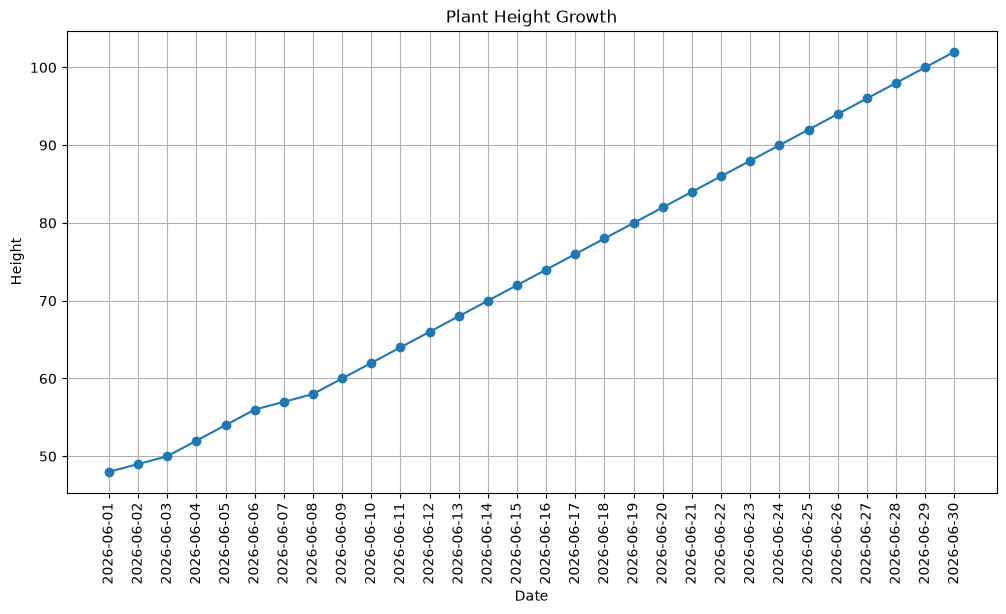

In [4]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Date"],
    df["Plant_Height_cm"],
    marker="o"
)

plt.xticks(rotation=90)
plt.title("Plant Height Growth")
plt.xlabel("Date")
plt.ylabel("Height")
plt.grid(True)
plt.show()

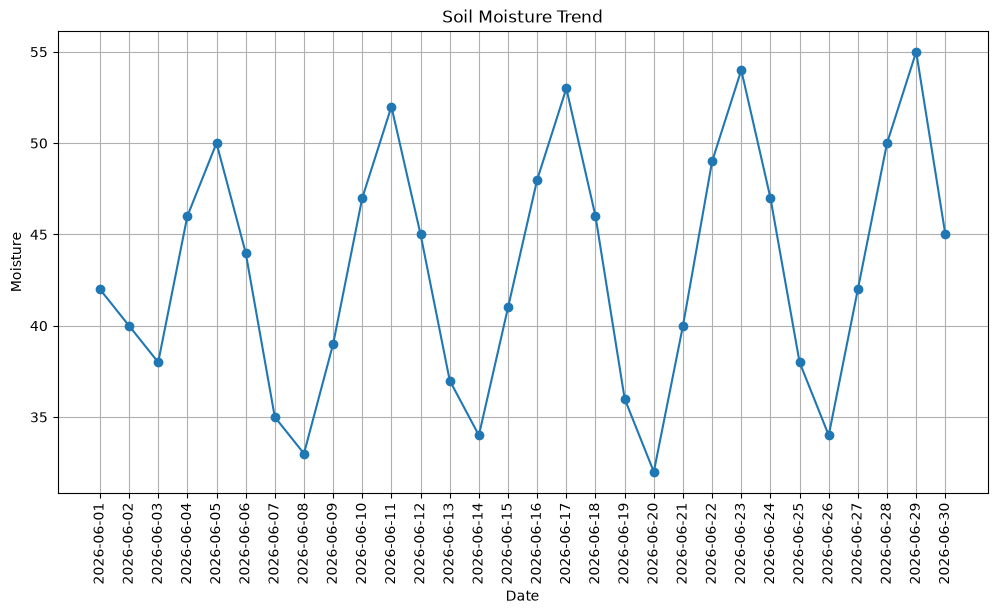

In [5]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Date"],
    df["Soil_Moisture_%"],
    marker="o"
)

plt.xticks(rotation=90)
plt.title("Soil Moisture Trend")
plt.xlabel("Date")
plt.ylabel("Moisture")
plt.grid(True)
plt.show()

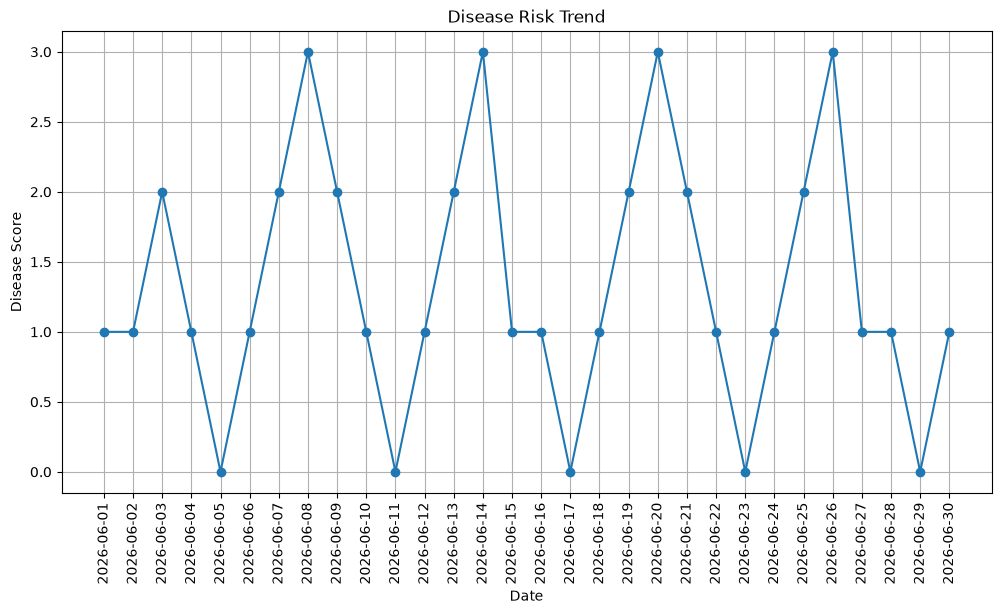

In [7]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Date"],
    df["Disease_Score"],
    marker="o"
)

plt.xticks(rotation=90)
plt.title("Disease Risk Trend")
plt.xlabel("Date")
plt.ylabel("Disease Score")
plt.grid(True)
plt.show()

In [8]:
def water_decision(moisture):
    if moisture < 38:
        return "Water Needed"
    else:
        return "No Water Needed"

df["Water_Advice"] = df["Soil_Moisture_%"].apply(
    water_decision
)

print(df[
    ["Soil_Moisture_%", "Water_Advice"]
].head())

   Soil_Moisture_%     Water_Advice
0               42  No Water Needed
1               40  No Water Needed
2               38  No Water Needed
3               46  No Water Needed
4               50  No Water Needed


In [9]:
def spray_decision(disease_score):
    if disease_score >= 2:
        return "Spray Needed"
    else:
        return "No Spray"

df["Spray_Advice"] = df["Disease_Score"].apply(
    spray_decision
)

print(df[
    ["Disease_Score", "Spray_Advice"]
].head())

   Disease_Score  Spray_Advice
0              1      No Spray
1              1      No Spray
2              2  Spray Needed
3              1      No Spray
4              0      No Spray


In [10]:
def fertilizer_decision(nitrogen):
    if nitrogen < 140:
        return "Add Fertilizer"
    else:
        return "No Fertilizer Needed"

df["Fertilizer_Advice"] = df["Nitrogen"].apply(
    fertilizer_decision
)

print(df[
    ["Nitrogen", "Fertilizer_Advice"]
].head())

   Nitrogen     Fertilizer_Advice
0       145  No Fertilizer Needed
1       142  No Fertilizer Needed
2       140  No Fertilizer Needed
3       150  No Fertilizer Needed
4       155  No Fertilizer Needed


In [11]:
df["Health_Score"] = (
    df["Leaf_Color_Index"] * 50
    - df["Disease_Score"] * 10
    + df["Soil_Moisture_%"] * 0.5
)

print(df[
    ["Date", "Health_Score"]
].head())

         Date  Health_Score
0  2026-06-01          50.0
1  2026-06-02          49.5
2  2026-06-03          37.5
3  2026-06-04          54.0
4  2026-06-05          67.0


In [12]:
features = [
    "Temp_C",
    "Humidity_%",
    "Rainfall_mm",
    "Soil_Moisture_%",
    "Leaf_Color_Index"
]

target = "Disease_Score"

X = df[features]
y = df[target]

print(X.head())
print(y.head())

   Temp_C  Humidity_%  Rainfall_mm  Soil_Moisture_%  Leaf_Color_Index
0      31          68           12               42              0.78
1      32          70            8               40              0.79
2      33          72            5               38              0.77
3      30          75           18               46              0.82
4      29          78           25               50              0.84
0    1
1    1
2    2
3    1
4    0
Name: Disease_Score, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(24, 5)
(6, 5)


In [14]:
from sklearn.ensemble import RandomForestClassifier

disease_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

disease_model.fit(X_train, y_train)

print("Disease model trained")

Disease model trained


In [15]:
from sklearn.metrics import accuracy_score

y_pred = disease_model.predict(X_test)

print("Disease Prediction Accuracy:",
      accuracy_score(y_test, y_pred))

Disease Prediction Accuracy: 1.0


In [16]:
sample = [[
    34,     # Temp
    80,     # Humidity
    20,     # Rainfall
    38,     # Soil moisture
    0.72    # Leaf color
]]

prediction = disease_model.predict(sample)

print("Predicted Disease Score:", prediction[0])

Predicted Disease Score: 2


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [17]:
from sklearn.preprocessing import LabelEncoder

growth_encoder = LabelEncoder()

df["Growth_Label"] = growth_encoder.fit_transform(
    df["Growth_Status"]
)

print(df[
    ["Growth_Status", "Growth_Label"]
].head())

  Growth_Status  Growth_Label
0        Normal             2
1        Normal             2
2          Slow             3
3          Good             1
4          Good             1


In [18]:
growth_features = [
    "Plant_Height_cm",
    "Leaf_Color_Index",
    "Soil_Moisture_%",
    "Disease_Score"
]

growth_target = "Growth_Label"

X = df[growth_features]
y = df[growth_target]

print(X.head())
print(y.head())

   Plant_Height_cm  Leaf_Color_Index  Soil_Moisture_%  Disease_Score
0               48              0.78               42              1
1               49              0.79               40              1
2               50              0.77               38              2
3               52              0.82               46              1
4               54              0.84               50              0
0    2
1    2
2    3
3    1
4    1
Name: Growth_Label, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.ensemble import RandomForestClassifier

growth_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

growth_model.fit(X_train, y_train)

print("Growth model trained")

Growth model trained


In [22]:
from sklearn.metrics import accuracy_score

y_pred = growth_model.predict(X_test)

print("Growth Model Accuracy:",
      accuracy_score(y_test, y_pred))

Growth Model Accuracy: 0.6666666666666666


In [23]:
sample_growth = [[
    75,     # Height
    0.78,   # Leaf color
    42,     # Moisture
    1       # Disease
]]

prediction = growth_model.predict(sample_growth)

result = growth_encoder.inverse_transform(
    prediction
)

print("Growth Status:", result[0])

Growth Status: Normal


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [24]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].head())

0   2026-06-01
1   2026-06-02
2   2026-06-03
3   2026-06-04
4   2026-06-05
Name: Date, dtype: datetime64[us]


In [25]:
df["Week"] = df["Date"].dt.isocalendar().week

print(df[["Date", "Week"]].head())

        Date  Week
0 2026-06-01    23
1 2026-06-02    23
2 2026-06-03    23
3 2026-06-04    23
4 2026-06-05    23


In [26]:
weekly_report = df.groupby("Week").agg({
    "Water_Given_Liters": "sum",
    "Fertilizer_Given_kg": "sum",
    "Plant_Height_cm": "mean",
    "Disease_Score": "mean",
    "Health_Score": "mean"
}).reset_index()

print(weekly_report)

   Week  Water_Given_Liters  Fertilizer_Given_kg  Plant_Height_cm  \
0    23                5370                   35        52.285714   
1    24                5640                   34        64.000000   
2    25                5530                   35        78.000000   
3    26                5230                   36        92.000000   
4    27                1290                   11       101.000000   

   Disease_Score  Health_Score  
0       1.142857     49.357143  
1       1.714286     42.642857  
2       1.428571     46.500000  
3       1.285714     49.928571  
4       0.500000     62.250000  


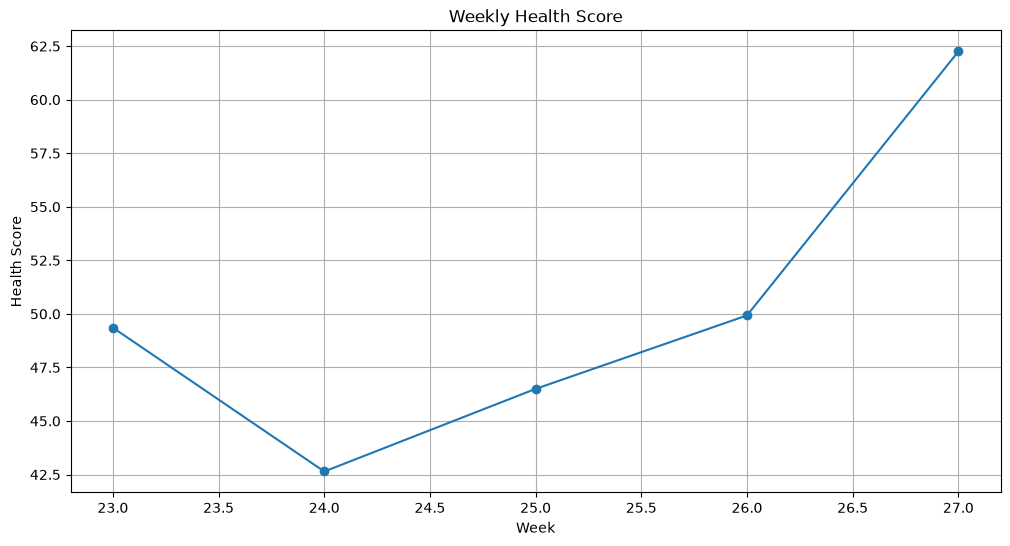

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    weekly_report["Week"],
    weekly_report["Health_Score"],
    marker="o"
)

plt.title("Weekly Health Score")
plt.xlabel("Week")
plt.ylabel("Health Score")
plt.grid(True)
plt.show()

In [28]:
def weekly_suggestion(disease, health):
    if disease > 2:
        return "Immediate Spray Needed"
    elif health < 40:
        return "Check Crop Health"
    else:
        return "Crop Healthy"

weekly_report["Suggestion"] = weekly_report.apply(
    lambda row: weekly_suggestion(
        row["Disease_Score"],
        row["Health_Score"]
    ),
    axis=1
)

print(weekly_report)

   Week  Water_Given_Liters  Fertilizer_Given_kg  Plant_Height_cm  \
0    23                5370                   35        52.285714   
1    24                5640                   34        64.000000   
2    25                5530                   35        78.000000   
3    26                5230                   36        92.000000   
4    27                1290                   11       101.000000   

   Disease_Score  Health_Score    Suggestion  
0       1.142857     49.357143  Crop Healthy  
1       1.714286     42.642857  Crop Healthy  
2       1.428571     46.500000  Crop Healthy  
3       1.285714     49.928571  Crop Healthy  
4       0.500000     62.250000  Crop Healthy  
